In [51]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import zscore
import matplotlib.gridspec as gridspec
from scipy.cluster import hierarchy
from scipy.stats import zscore
from scipy.spatial import KDTree
import squidpy as sq
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


sns.set_style('whitegrid')
sns.set_context('notebook')

In [3]:
# load data
DATA_PATH = "data/train_adata.h5ad"
adata = ad.read_h5ad(DATA_PATH)
adata.layers['exprs_arcsinh'] = adata.layers['exprs'] # already arcsinh(x/5)
adata.obsm['spatial'] = adata.obs[['Pos_X', 'Pos_Y']].values

## Task 1

**Goal:** Familiarise yourself with the AnnData object and report fundamental properties of the dataset.

**Deliverable:** A formatted table (printed DataFrame or markdown) containing:
1. Number of cells, markers, images, and cancer indications.
2. All 14 cell-type labels with absolute cell counts, sorted descending.
3. The fraction of cells classified as Tumor (to one decimal place).

In [4]:
# Prepare dataframe
tumor_fraction = (adata.obs['celltypes'] == 'Tumor').mean()

data = {
    "Metric": [
        "Total Cells", "Total Markers", "Total Images", "Total Indications"
    ] + list(adata.obs["celltypes"].unique()) + ["Tumor Fraction"],
    
    "Value": [
        adata.n_obs, adata.n_vars, adata.obs['image'].nunique(), 
        adata.obs['Indication'].nunique()
    ] + list(adata.obs['celltypes'].value_counts().values) + [round(tumor_fraction, 1)]
}
table_df = pd.DataFrame(data)

In [5]:
table_df

,Metric,Value
0,Total Cells,253433.0
1,Total Markers,40.0
2,Total Images,132.0
3,Total Indications,5.0
4,MacCD163,138266.0
5,Mural,22722.0
6,DC,20537.0
7,Tumor,15288.0
8,CD4,13238.0
9,HLADR,7872.0


## Task 2

**Goal:** Examine how the arcsinh-transformed expression of selected markers is distributed across all cells.

**Deliverable:** 
A single figure with three subplots - one each for Ecad (epithelial), CD8a (cytotoxic T
cell), and Ki67 (proliferation). Each subplot shows the expression histogram across all cells with labelled
axes. Add one annotation sentence per panel stating whether the distribution is unimodal or bimodal
and what this implies about cell-type specificity.

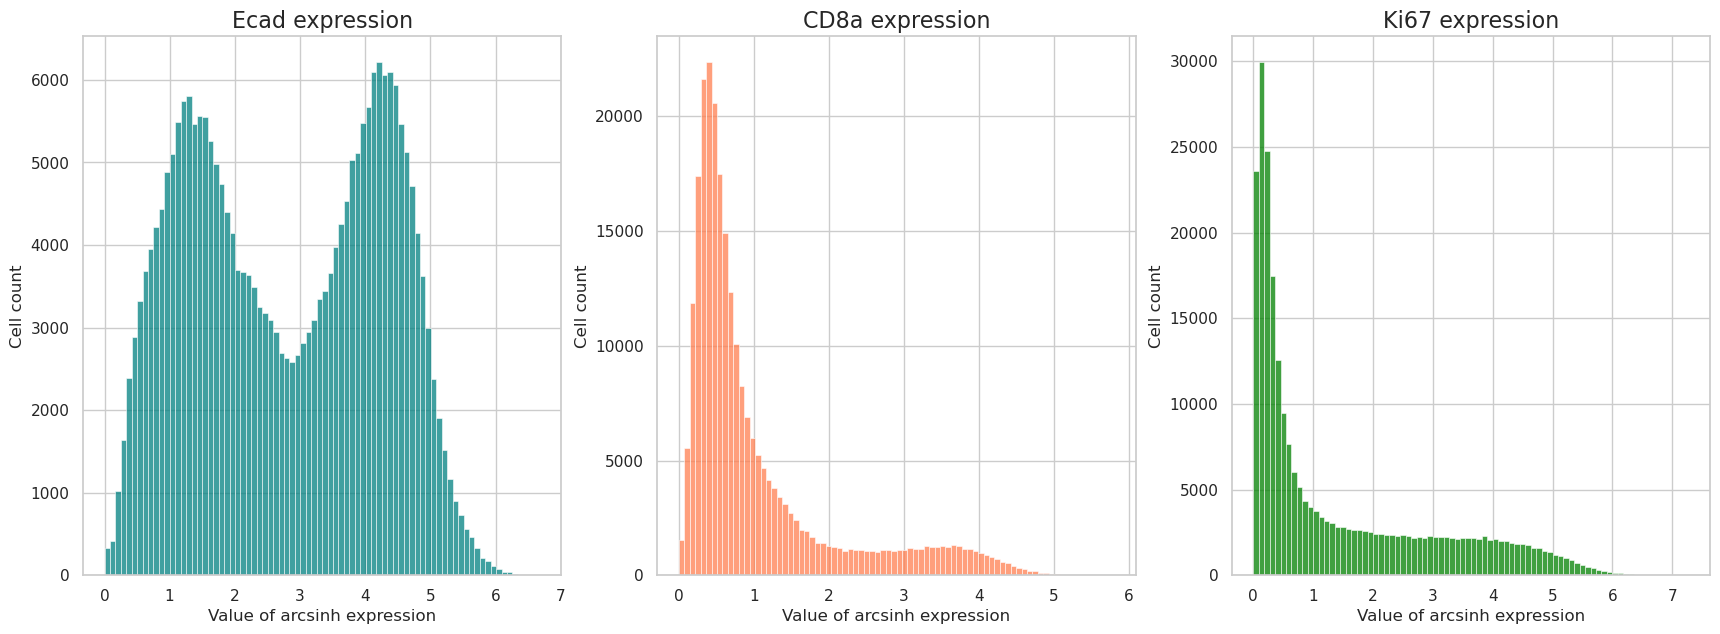

In [6]:
markers = ["Ecad", "CD8a", "Ki67"]
colors = ["teal", "coral", "green"]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# Iterate over markers and axes
for i, marker in enumerate(markers):
    ax = axes[i]
    col = np.where(adata.var['marker'] == marker)[0][0]
    expr = adata.layers['exprs_arcsinh'][:, col]
    sns.histplot(expr, bins=80, ax=ax, color=colors[i])

    ax.set_title(f"{marker} expression", fontsize=16)
    ax.set_xlabel("Value of arcsinh expression", fontsize=12)
    ax.set_ylabel("Cell count", fontsize=12)



**Panel 1:**

Możemy zauważyć, że dla markeru Ecad dane rozłożone są w sposób bimodalny (dwa rożne piki). Mówi to nam, że dla tego markeru istnieje podział na dwie różne względem siebie grupy komórkowe - takie, które praktycznie nie wykazują ekspresji tego genu i takie dla, których jest bardzo charakterystyczna co pozwala nam zastosować go do potencjalnego odróżnienia komórek nowotworowych od zdrowych.

**Panel 2 i 3:**

W tym przypadku mamy do czynienia z rozkładem unimodalnym co można interpretować jako to, że marker sam w sobie nie definiuje nam konkretnego typu komórkowego. 

## Task 3

**Goal:** Quantify how tumour-cell fraction and key tumour marker expression vary by cancer type, and
determine whether indications cluster by their tumour molecular profile.

**Deliverables:** 
1. A barplot of Tumor cell fraction per indication (sorted descending).
2. A heatmap of z-scored Ecad, CarbonicAnhydrase, and Ki67 expression in Tumor cells per indica-
tion, with a dendrogram showing hierarchical clustering of indications.
3. Two sentences: which indications cluster together, and what does the shared marker profile suggest
biologically?

In [7]:
tumor_frac = (
    adata.obs
    .groupby("Indication", observed=True)["celltypes"] # grupujemy po indikacji i subsetujemy kolumnę z typami komórek
    .apply(lambda s: (s == "Tumor").mean()) # dla każdej grupy obliczamy średnią, która odpowiada frakcji komórek nowotworowych
    .rename("Tumor_fraction") 
    .sort_values(ascending=False)
    .reset_index()
)

tumor_frac

,Indication,Tumor_fraction
0,HN,0.678782
1,GI,0.535670
2,THOR,0.531939
3,BREAS,0.516139
4,GU,0.455558


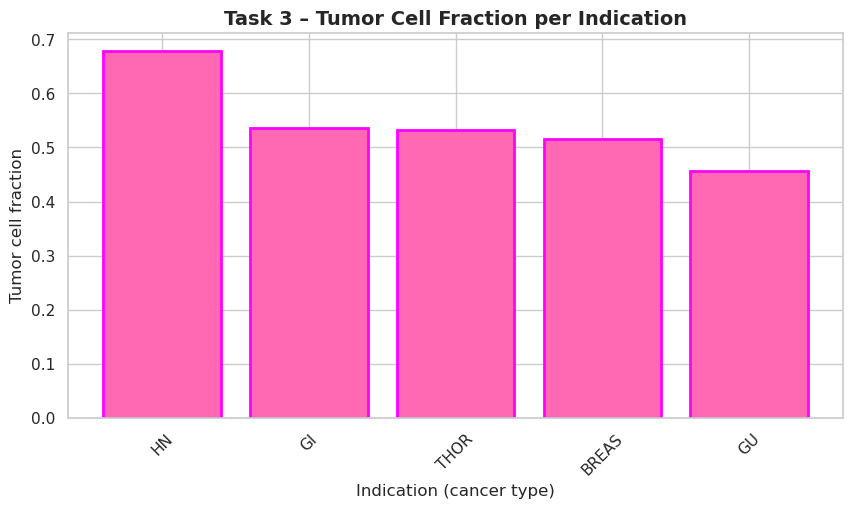

In [8]:
# Wykre słupkowy frakcji komórek nowotworowych dla każdej indikacji
plt.rcParams['figure.dpi'] = 100
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(
    tumor_frac["Indication"],
    tumor_frac["Tumor_fraction"],
    color="hotpink",
    edgecolor="magenta",
    linewidth=2
)
ax1.set_xlabel("Indication (cancer type)", fontsize=12)
ax1.set_ylabel("Tumor cell fraction", fontsize=12)
ax1.set_title("Task 3 – Tumor Cell Fraction per Indication", fontsize=14, fontweight="bold")
ax1.tick_params(axis="x", rotation=45)

In [9]:
# obliczenie średniej ekspresji arcsinh dla trzech markerów w komórkach nowotworowych
MARKERS = ["Ecad", "CarbonicAnhydrase", "Ki67"]

# subsetujemy tylko komórki nowotworowe
adata_tumor = adata[adata.obs["celltypes"] == "Tumor"].copy() # nie chcemy nic popsuć

# dataframe z arcsinh ekspresją markerów 
expr_df = pd.DataFrame(
    adata_tumor.layers["exprs_arcsinh"],
    index=adata_tumor.obs_names,
    columns=adata_tumor.var["marker"].values
)

# checmy tylko te 3 markery, które nas interesują
expr_df = expr_df[MARKERS]
expr_df["Indication"] = adata_tumor.obs["Indication"].values

# średnia ekspresja 3 markerów w komórkach nowotworowych dla każdej indikacji
marker_df = (
    expr_df
    .groupby("Indication", observed=True)[MARKERS]
    .mean()
)

marker_df

,Ecad,CarbonicAnhydrase,Ki67
Indication,,,
BREAS,4.335988,1.909136,2.231839
GI,3.863488,1.557918,2.169100
GU,1.495726,3.894414,0.389315
HN,4.321932,2.436929,2.535008
THOR,3.474983,1.451339,1.916187


In [10]:
# klastrowanie hierarchiczne
linkage = hierarchy.linkage(marker_df, method="ward")

# z-score normalizacja
zdf = pd.DataFrame(
    zscore(marker_df.values, axis=0),
    index=marker_df.index,
    columns=marker_df.columns
)

Text(0.5, 1.02, 'Task 3 – Z-scored Marker Expression in Tumor Cells\n(Ward hierarchical clustering of indications)')

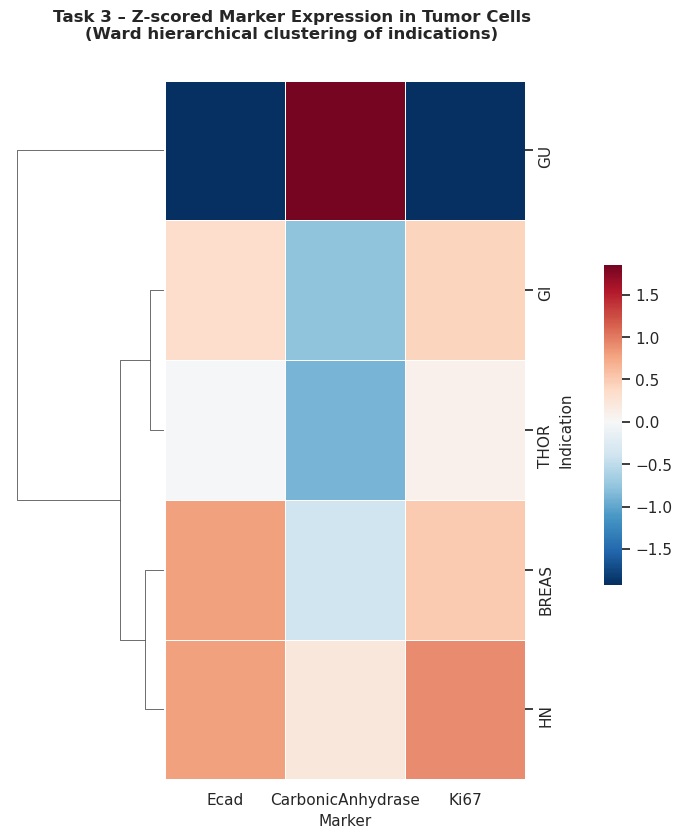

In [11]:
plt.rcParams['figure.dpi'] = 100

cg = sns.clustermap(
    zdf,
    row_linkage=linkage,
    col_cluster=False,          # keep Ecad → CarbonicAnhydrase → Ki67 order
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    figsize=(6, 8),
    dendrogram_ratio=(0.3, 0.05),
    cbar_pos=(1.02, 0.3, 0.03, 0.4),
)
cg.ax_heatmap.set_xlabel("Marker", fontsize=11)
cg.ax_heatmap.set_ylabel("Indication", fontsize=11)
cg.fig.suptitle(
    "Task 3 – Z-scored Marker Expression in Tumor Cells\n(Ward hierarchical clustering of indications)",
    y=1.02, fontsize=12, fontweight="bold")

 ### Interpretacja

 Indykacje klastruje się na 2 klastry, 1 składający się z HN, BREAS, THOR, GI, w ramach niego są 2 podklastry - HN I BREAS oraz THOR i GI. 2 składa się wyłącznie z GU.
 
 W klastrze 1.1 (HN i BREAS) ekspresja Ecad i Ki67 jest zwiększona a Anhydraza oscyluje blisko wartości zdrowej komórki.
 W klastrze 1.2 (ThOR i GI) ekspresja Ecad i Ki67 również jest zwiększona bądź bliska wartości normalnej a Anhydraza ulega znacznemu osłabieniu.
 Oznacza to że nowotwory te są przystosowane do życia w środowisku gdzie tlen jest dostępny - środowisko nie jest zakwaszone, szczególnie w przypadku klastra 1.2 .

 Natomiast klaster 2 składający się wyłącznie z GU wykazuje bardzo silnie osłabienie w Ecad i Ki67 jak i podwyższenie Anhydrazy - przystosowanie do warunków beztlenowych - zakwaszonych.



## Task 4

**Goal:** Select one image using a quantitative criterion and visualise both the spatial cell-type organisation
and the within-image heterogeneity of a biologically relevant marker

**Deliverable:**
1. Your chosen criterion (including the minimum Tumor cell filter used), the selected image ID, and
the criterion value.
2. A two-panel figure for that image: left - scatter plot coloured by cell type; right - scatter plot of
all cells coloured by the continuous expression of your chosen marker.
3. One sentence comparing the two panels: does the marker's spatial pattern align with or deviate
from the cell-type boundaries?

For the criterion i've used CD8/Tumor cell ratio. I also limit images to those that have more Tumor cells than CD8 cells.

In [12]:
min_tumor = 500
results=[]

for image in adata.obs["image"].unique():

    cell_counts = adata[adata.obs["image"]==image].obs["celltypes"].value_counts()

    if "CD8" not in cell_counts or "Tumor" not in cell_counts:
        continue

    cd8_count = cell_counts["CD8"]
    tumor_count = cell_counts["Tumor"]

    # filtering out small tumor sized images and images where most of cells are CD8 cells.
    if tumor_count < 1000 or cd8_count > tumor_count:
        continue

    criterion = np.round(cd8_count/tumor_count, 2)

    results.append({"image": image, "criterion_value": criterion})

df = pd.DataFrame(results)
df = df.sort_values(by="criterion_value", ascending=False)
df.head(1)

,image,criterion_value
56,IMMUcan_Batch20220609_S-220218-00008_003.tiff,0.83


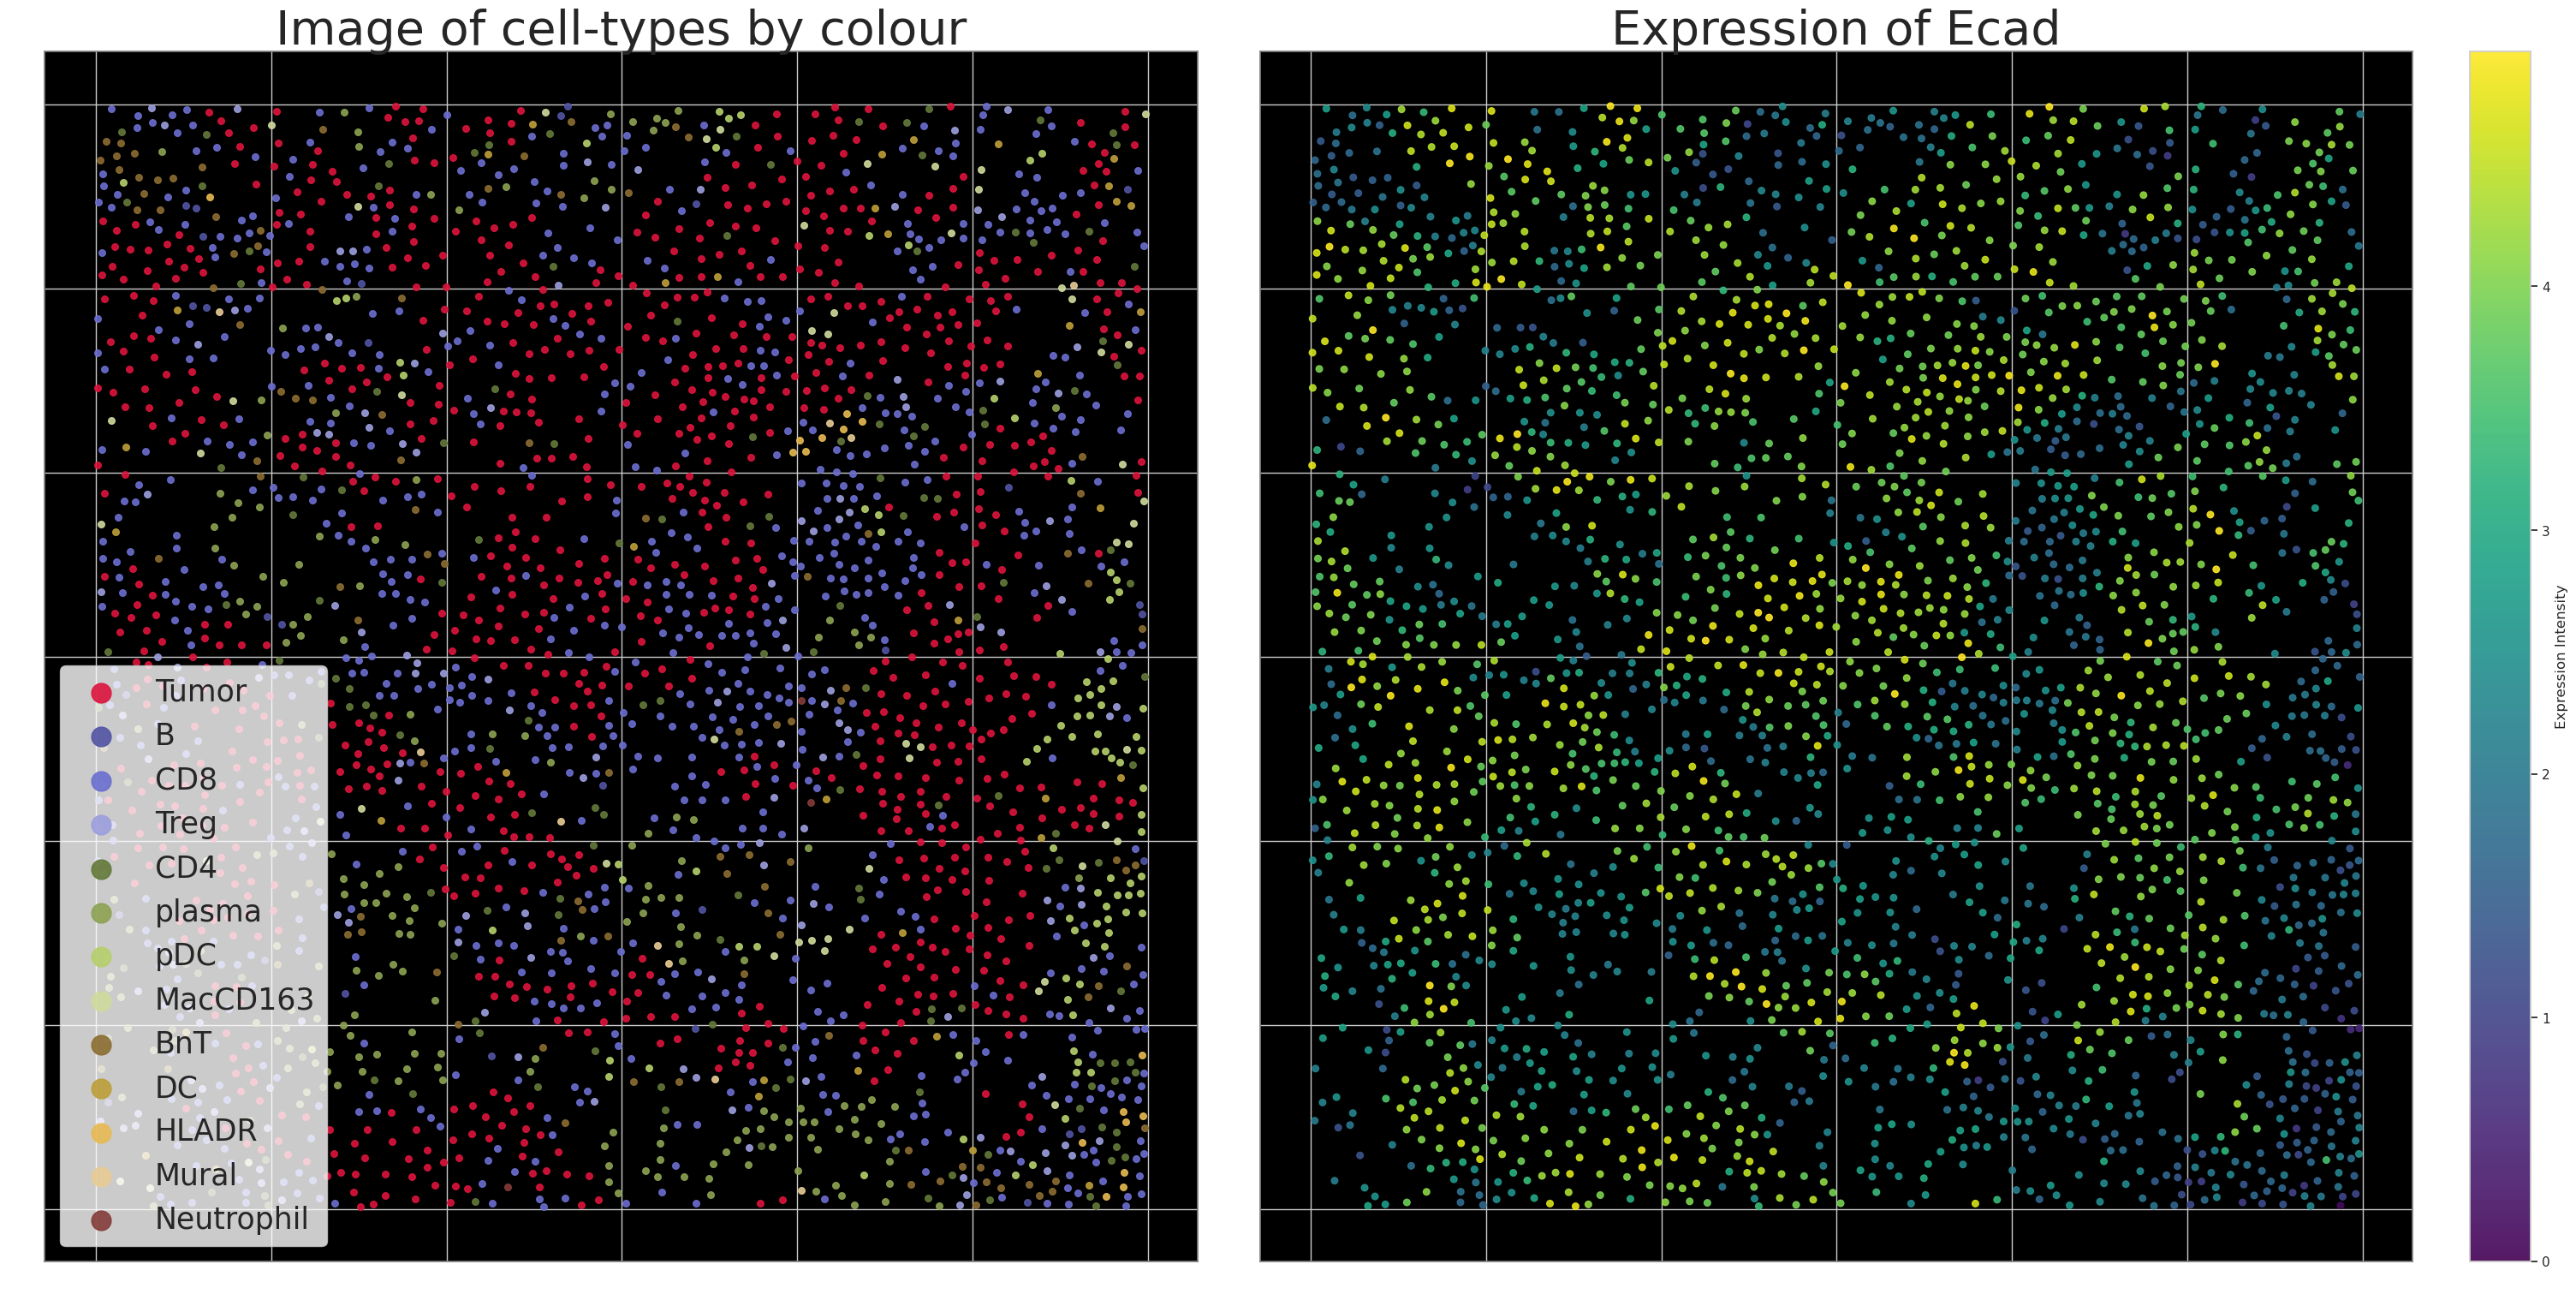

In [13]:
IMAGE_ID = df.head(1)["image"].values[0]
adata_img = adata[adata.obs["image"] == IMAGE_ID].copy()
coords = adata_img.obsm["spatial"]
marker_to_map = "Ecad"

# create two axes
fig, axes = plt.subplots(1, 2, figsize=(30, 15), constrained_layout=True)

# black background for better visualization
for ax in axes:
    ax.set_facecolor('black')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('grey')

ax1 = axes[0]

# Choose unique celltypes and colors for it.
celltypes = adata_img.obs["celltypes"].unique()

# color palette
cmap = plt.get_cmap("tab20b")
color_dict = {
    ct: cmap(i) 
    for i, ct in enumerate(celltypes)
}

# Make sure tumor is different and vivid color.
color_dict["Tumor"] = "crimson"

# color each celltype
for ct in celltypes:
    m = adata_img.obs['celltypes'] == ct
    ax1.scatter(coords[m, 0], coords[m, 1], s=30,
                 alpha=0.9, color=color_dict[ct], label=ct)

ax1.set_title("Image of cell-types by colour", fontsize=40)
ax1.invert_yaxis()
ax1.legend(markerscale=3, fontsize=25)

# right plot
ax2 = axes[1]

# color each cell by it's expression of selected marker
m_idx = np.where(adata_img.var['marker'] == marker_to_map)[0]
marker_expr = adata_img.layers['exprs_arcsinh'][:, m_idx[0]]
sc = ax2.scatter(
            coords[:, 0], coords[:, 1],
            c=marker_expr, cmap='viridis',
            s=30, alpha=0.9, rasterized=True,
            vmin=0, vmax=np.percentile(marker_expr, 99)
        )

ax2.set_title(f"Expression of Ecad", fontsize=40)
ax2.invert_yaxis()
plt.colorbar(sc, ax=ax2, label='Expression Intensity')
plt.show()

Możemy zauważyć, że ekspresja naszego markeru "Ecad" w bardzo dobry sposób odróżnia komórki nowotworowe od innych typów (widać w tych samych miejscach co "tumor" cell zwiększoną ekspresję), wiec tak sygnał tego markera pozostaje zgodny z granicami typów komórkowych, aczkolwiek są miejsca gdzie radzi sobie on gorzej.

## Task 5


**Goal:** Quantify which cell types preferentially co-localise with Tumor cells using Squidpy's graph-based
neighbourhood test.

**Deliverables:** 
1. The neighbourhood enrichment heatmap (sq.pl.nhood_enrichment(adata_s,
cluster_key='celltypes')).
2. In plain text: the top-2 cell types most enriched next to Tumor (highest z-score in the Tumor row),
the Tumor self-enrichment z-score, and whether CD8 cells are enriched or depleted around Tumor
in this image.


In [14]:
# selekcja obrazu
adata_s = adata[adata.obs["image"] == IMAGE_ID].copy()


In [15]:
# dodanie współrzędnych przestrzennych do obiektu AnnData
adata_s.obsm["spatial"] = np.column_stack([
    adata_s.obs["Pos_X"].values,
    adata_s.obs["Pos_Y"].values
])

In [16]:
# budowa grafu sąsiedztwa
sq.gr.spatial_neighbors(
    adata_s,
    coord_type="generic",
    spatial_key="spatial",
    n_neighs=10
)

In [17]:
# obliczenie wzbogacenia sąsiedztwa
sq.gr.nhood_enrichment(adata_s, cluster_key="celltypes")

/home/Latrynator/miniconda3/envs/bs3_stable/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 1000/1000 [00:00<00:00, 4317.71/s]


In [18]:
# macierz z-score wzbogacenia sąsiedztwa
zscore_matrix = adata_s.uns["celltypes_nhood_enrichment"]["zscore"]
cell_types = adata_s.obs["celltypes"].cat.categories.tolist()
zscore_df = pd.DataFrame(zscore_matrix, index=cell_types, columns=cell_types)

zscore_df

,B,BnT,CD4,CD8,DC,HLADR,MacCD163,Mural,Neutrophil,Treg,Tumor,pDC,plasma
B,4.701911,4.656509,0.827658,-1.784636,1.341245,2.557789,-0.839054,0.812726,-0.610214,1.611077,-7.572760,2.327977,5.017035
BnT,3.653875,13.792224,2.217542,5.240439,-2.206465,-0.526507,-0.865832,0.077898,-0.136730,4.674347,-16.770717,4.844946,3.311170
CD4,0.851847,1.802169,3.928978,2.497004,2.837608,5.456135,-0.120151,0.464482,0.176322,1.483080,-8.269048,0.645258,1.725192
CD8,-0.769575,4.886007,2.812296,17.717847,-0.507053,3.809874,-1.993462,-0.753945,2.938330,7.980699,-23.387855,-4.280057,-3.660832
DC,2.393371,-1.567798,2.603543,0.238161,3.389860,-0.813402,3.866962,-1.203935,0.948523,0.209018,-0.634341,0.593599,-3.240465
HLADR,1.731625,-0.519524,5.048108,3.517262,-0.824844,22.641663,-1.808414,8.391796,-0.411395,-1.836987,-7.432956,-1.937009,-3.245982
MacCD163,-1.289894,-1.327159,-0.483754,-3.405277,3.171013,-1.803513,11.020732,0.023608,-0.782356,-0.688079,-1.673408,4.336912,-4.305546
Mural,0.773915,0.072847,0.493517,-0.332381,-0.335265,9.939148,0.000724,4.986487,-0.345913,0.477924,-1.972906,-1.842875,3.007791
Neutrophil,-0.634317,-0.119653,0.205826,2.408737,0.907058,-0.411288,-0.765049,-0.343121,-0.124613,2.058805,-1.794854,-1.006578,-0.766705
Treg,1.664205,4.486217,1.997549,6.988960,-0.030533,-1.810353,-0.284779,0.023109,1.212699,6.299072,-12.787111,2.073226,-0.727459


/home/Latrynator/miniconda3/envs/bs3_stable/lib/python3.11/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/Latrynator/miniconda3/envs/bs3_stable/lib/python3.11/site-packages/squidpy/pl/_utils.py:555: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row_labels = adata.obs[key][row_order]


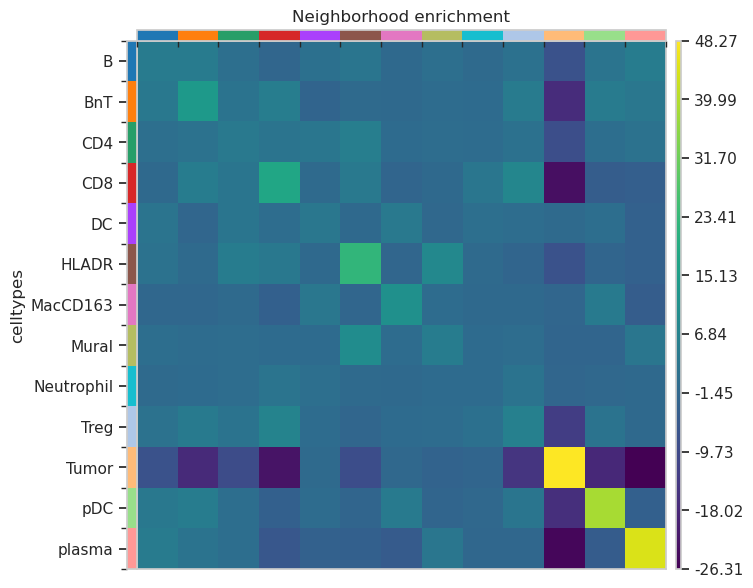

In [19]:
plt.rcParams['figure.dpi'] = 100
fig5, ax5 = plt.subplots(figsize=(8, 7))
sq.pl.nhood_enrichment(adata_s, cluster_key="celltypes", ax=ax5)

In [20]:
# interpretacja wykresu

# ustalenie top-2 typów komórek współlokalizujących się z komórkami nowotworowymi
tumor_row = zscore_df.loc["Tumor"].drop("Tumor")  # należy wykluczyć samą siebie, bo zawsze będzie wzbogacona
top2 = tumor_row.sort_values(ascending=False).head(2)
print(f"\ntop-2 cell types co-localising with Tumor: {top2.index.tolist()} (z = {top2.values.round(2).tolist()})")

# własne wzbogacenie
self_enrichment = zscore_df.loc["Tumor", "Tumor"]
print(f"Tumor self-enrichment z-score: {self_enrichment:.2f}")


# sprawdzenie wzbogacenia CD8
cd8_score = zscore_df.loc["Tumor", "CD8"] if "CD8" in cell_types else None

if cd8_score:
    enriched = "enriched" if cd8_score > 0 else "depleted"
    print(f"CD8 cells are {enriched} around Tumor cells (z = {cd8_score:.2f})")
else:
    print("CD8 not found as a cell-type label in this image.")



top-2 cell types co-localising with Tumor: ['DC', 'MacCD163'] (z = [-0.58, -1.18])
Tumor self-enrichment z-score: 48.27
CD8 cells are depleted around Tumor cells (z = -22.46)


## Task 6 

**Goal:** Characterise the local immune microenvironment of Tumor cells across all 132 images by exam-
ining the cell-type composition of their nearest spatial neighbours.

**Deliverables:** 
A horizontal barplot of weighted-mean neighbour cell-type fractions around Tumor cells
across all images, sorted descending (exclude the Tumor category itself). One sentence stating which
non-Tumor cell type is most frequently adjacent to Tumor cells.

In [21]:
weighted_fractions = {}   
total_tumor_cells  = 0    

images = adata.obs["image"].unique()

for img in images:
    
    sub = adata[adata.obs["image"] == img]
    coords = sub.obs[["Pos_X", "Pos_Y"]].values.astype(float)
    cell_labels = sub.obs["celltypes"].astype(str).values 

    tumor_idx = np.where(cell_labels == "Tumor")[0]
    n_tumor = len(tumor_idx)

    if n_tumor == 0:
        continue   # jeżeli nie ma komórek nowotworowych, to nie ma co liczyć sąsiedztwa

    # budowa drzewa
    tree = KDTree(coords)

    # query z współrzędnych komórek nowotworowych; k=11, bo index 0 to komórka zapytania
    tumor_coords = coords[tumor_idx]
    dists, indices = tree.query(tumor_coords, k=11)   

    # zbiórka 10 najbliższych sąsiadów
    neighbour_types = cell_labels[indices[:, 1:]]

    # spłaszczenie i zliczenie (wykluczając sąsiadów typu Tumor, bo interesuje nas skład immunologiczny)
    flat = neighbour_types.flatten()
    non_tumor = flat[flat != "Tumor"]

    if len(non_tumor) == 0: # jeżeli nie ma żadnych sąsiadów innych niż Tumor, to nie ma co liczyć frakcji
        continue

    # frakcja każdego typu komórek nie-Tumor w sąsiedztwie tego obrazu
    unique, counts = np.unique(non_tumor, return_counts=True)
    fracs = counts / len(non_tumor)

    # ważona suma frakcji 
    for ct, frac in zip(unique, fracs):
        weighted_fractions[ct] = weighted_fractions.get(ct, 0.0) + frac * n_tumor

    total_tumor_cells += n_tumor

# Compute weighted mean fractions
weighted_mean = {ct: wsum / total_tumor_cells for ct, wsum in weighted_fractions.items()}
neighbour_df = (
    pd.Series(weighted_mean, name="Weighted_mean_fraction")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "CellType"})
)

neighbour_df

,CellType,Weighted_mean_fraction
0,Mural,0.212010
1,CD8,0.205713
2,MacCD163,0.151308
3,Neutrophil,0.107576
4,CD4,0.091129
5,DC,0.070727
6,Treg,0.062619
7,HLADR,0.049921
8,plasma,0.025729
9,B,0.007281


In [22]:
print(f"\nMost frequent non-Tumor neighbour: {neighbour_df.iloc[0]['CellType']}")


Most frequent non-Tumor neighbour: Mural


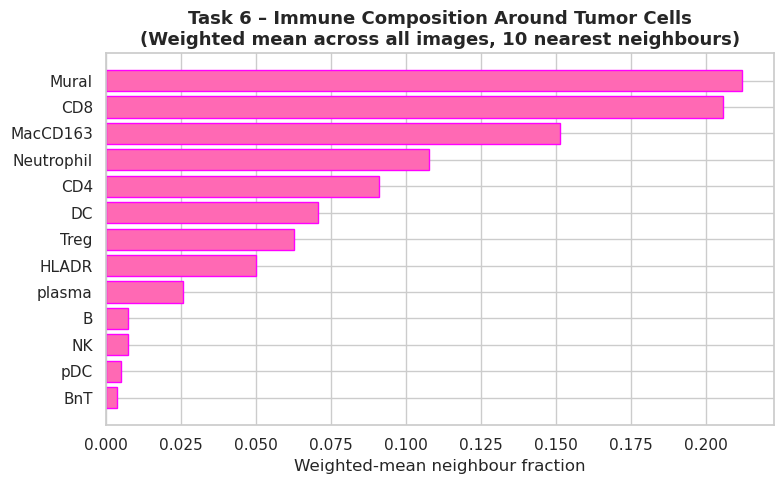

In [23]:
# wykres
fig6, ax6 = plt.subplots(figsize=(8, 5))
ax6.barh(
    neighbour_df["CellType"],
    neighbour_df["Weighted_mean_fraction"],
    color="hotpink",
    edgecolor="magenta",
    linewidth=1
)
ax6.invert_yaxis()  
ax6.set_xlabel("Weighted-mean neighbour fraction", fontsize=12)
ax6.set_title(
    "Task 6 – Immune Composition Around Tumor Cells\n(Weighted mean across all images, 10 nearest neighbours)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()


## Task 7

**Goal:** Identify subpopulations within Tumor cells using unsupervised clustering, and select the number
of clusters through systematic evaluation.

**Deliverables:** 
1. Chosen marker panel with justification.
2. Elbow (inertia) and silhouette plots for k = 3 to 7.
3. Selected k with one sentence explaining why.
4. Spatial scatter plot of Tumor cells coloured by cluster label.

### Wybór markerów:

Zdecydowaliśmy się wybrać następujący zestaw markerów (nie było to trudne, lwia część markerów to markery komórek immunologicznych):

In [ ]:
TASK7_MARKERS = ['Ecad', 'Ki67', 'CarbonicAnhydrase', 'cleavedPARP', 'PDL1', 'Ido1', 'VISTA']

Ponieważ ilustrują one dobrze działanie i życie nowotworu - proliferacja, przetrwanie w niedotlenieniu, ukrywanie się przed systemem immunologicznym oraz śmierci.

In [ ]:
# filtracja wybranego obrazu
image_4 = (adata.obs["image"] == IMAGE_ID) & (adata.obs["celltypes"] == "Tumor")
tumor_4 = adata[image_4].copy() # nie chcemy nic popsuć

AnnData object with n_obs × n_vars = 1031 × 40
    obs: 'image', 'sample_id', 'ObjectNumber', 'Pos_X', 'Pos_Y', 'area', 'major_axis_length', 'minor_axis_length', 'eccentricity', 'width_px', 'height_px', 'acquisition_id', 'SlideId', 'Study', 'Box.Description', 'Position', 'SampleId', 'Indication', 'BatchId', 'SubBatchId', 'ROI', 'ROIonSlide', 'includeImage', 'flag_no_cells', 'flag_no_ROI', 'flag_total_area', 'flag_percent_covered', 'small_cell', 'celltypes', 'flag_tumor', 'PD1_pos', 'Ki67_pos', 'cleavedPARP_pos', 'GrzB_pos', 'tumor_patches', 'distToCells', 'CD20_patches', 'Batch', 'cell_labels', 'classifier'
    var: 'channel', 'use_channel', 'marker'
    obsm: 'spatial'
    layers: 'exprs', 'exprs_arcsinh'

In [49]:
# 
marker_to_idx = {m: i for i, m in enumerate(tumor_4.var["marker"].values)}
col_idx = [marker_to_idx[m] for m in TASK7_MARKERS]

X_raw = tumor_4.layers["exprs_arcsinh"][:, col_idx]   # (n_cells, n_markers)


In [50]:
# skalowanie standardowe
X = StandardScaler().fit_transform(X_raw)

In [ ]:
K_RANGE = [3, 4, 5, 6, 7]
inertias   = []
silhouettes = []
all_labels  = {}

# klastrowanie KMeans dla różnych k i obliczanie metryk
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels, sample_size=min(5000, len(labels)), random_state=42)
    silhouettes.append(sil)
    all_labels[k] = labels

K_range_df = pd.DataFrame({"k": K_RANGE, "inertia": inertias, "silhouette": silhouettes})
K_range_df


,k,inertia,silhouette
0,3,4238.498293,0.168678
1,4,3837.304339,0.169787
2,5,3498.596287,0.162616
3,6,3213.839851,0.169473
4,7,3030.115145,0.152299


/tmp/ipykernel_7975/4264537021.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_elbow.legend()
/tmp/ipykernel_7975/4264537021.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_sil.legend()


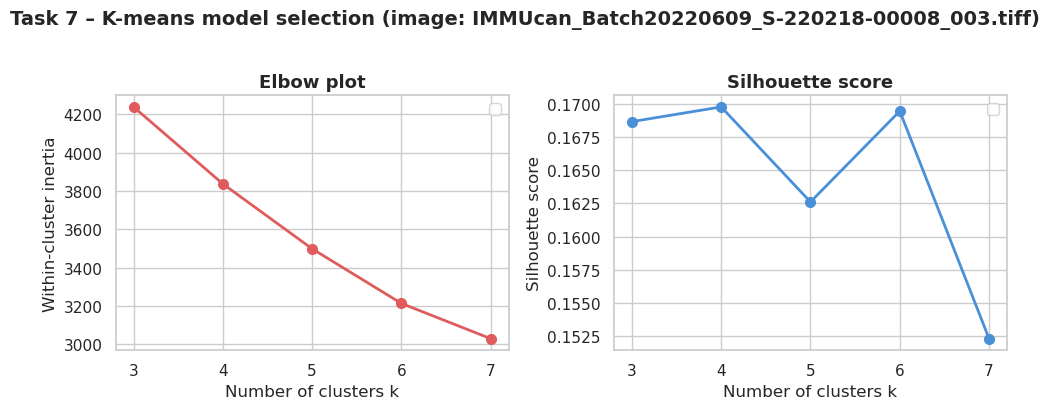

In [ ]:
fig1, (ax_elbow, ax_sil) = plt.subplots(1, 2, figsize=(10, 4))

# Elbow
ax_elbow.plot(K_RANGE, inertias, "o-", color="#e05c5c", linewidth=2, markersize=7)
ax_elbow.set_xlabel("Number of clusters k", fontsize=12)
ax_elbow.set_ylabel("Within-cluster inertia", fontsize=12)
ax_elbow.set_title("Elbow plot", fontsize=13, fontweight="bold")
ax_elbow.set_xticks(K_RANGE)
ax_elbow.legend()

# Silhouette
ax_sil.plot(K_RANGE, silhouettes, "o-", color="#4a90d9", linewidth=2, markersize=7)
ax_sil.set_xlabel("Number of clusters k", fontsize=12)
ax_sil.set_ylabel("Silhouette score", fontsize=12)
ax_sil.set_title("Silhouette score", fontsize=13, fontweight="bold")
ax_sil.set_xticks(K_RANGE)
ax_sil.legend()

fig1.suptitle(
    f"Task 7 – K-means model selection (image: {IMAGE_ID})",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()

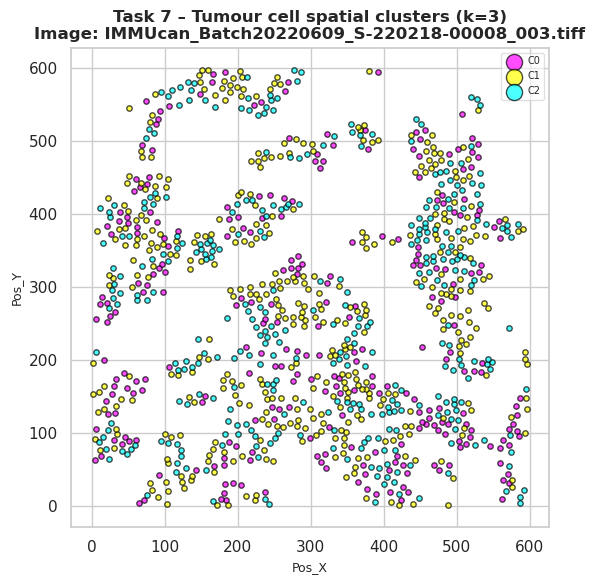

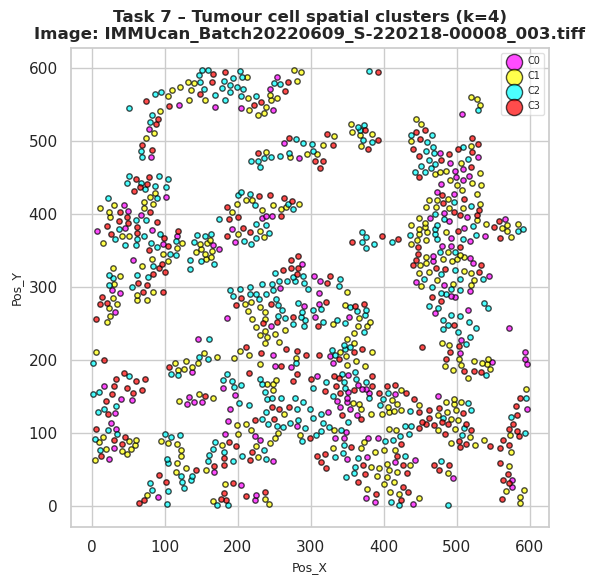

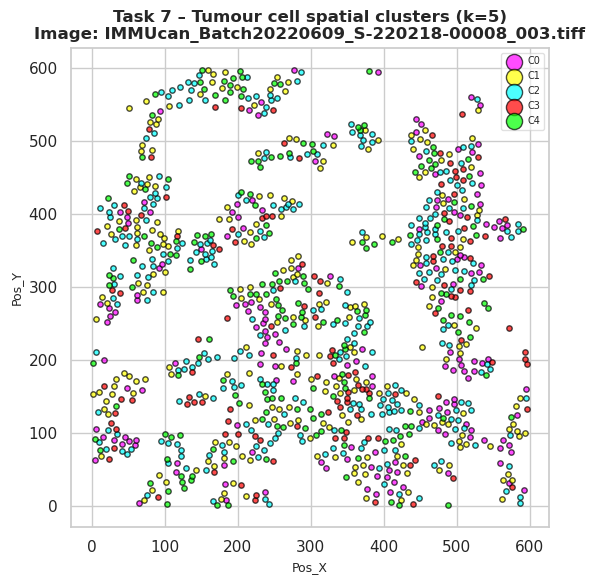

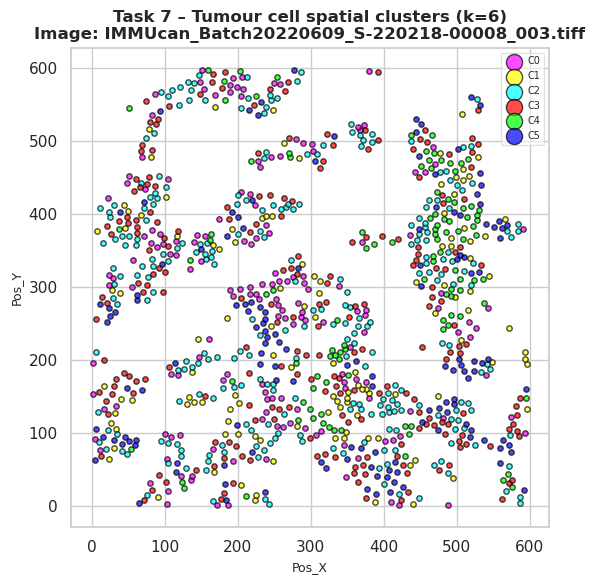

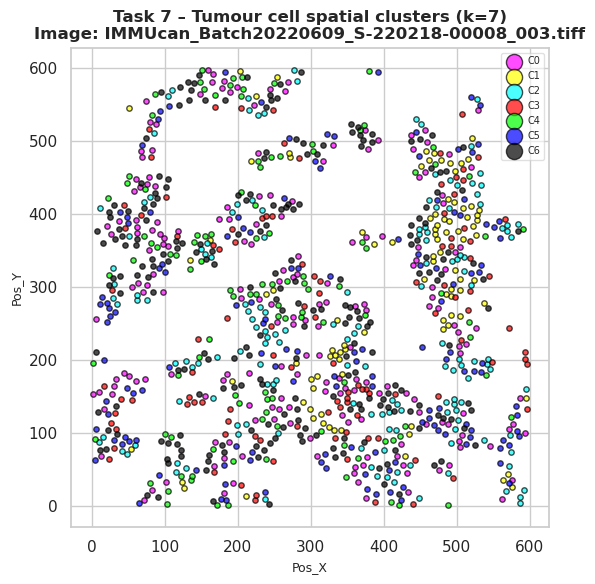

In [78]:
pos_x = tumor_4.obs["Pos_X"].values
pos_y = tumor_4.obs["Pos_Y"].values

palette = ["magenta", "yellow", "cyan", "red", "lime", "blue", "black"] # śliczne kolorki dla klastrów :D

for k in K_RANGE:
    fig, ax = plt.subplots(figsize=(6, 6))
    labels_k = all_labels[k]
    for c in range(k):
        idx = labels_k == c
        ax.scatter(
            pos_x[idx], pos_y[idx],
            s=15, alpha=0.7,
            color=palette[c],
            label=f"C{c}",
            linewidths=1,
            edgecolors='black'
        )
    ax.set_xlabel("Pos_X", fontsize=9)
    ax.set_ylabel("Pos_Y", fontsize=9)
    ax.set_aspect("equal")
    ax.legend(markerscale=3, fontsize=7, loc="best",
              framealpha=0.6, handletextpad=0.3)
    ax.set_title(
        f"Task 7 – Tumour cell spatial clusters (k={k})\nImage: {IMAGE_ID}",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()


### Najlepsze K
Naszym zdaniem najlepsze K to 4, ponieważ ma maksymalne silhuette, dodatkowo liczba 4 pasuje do 4 warunków przeżycia nowotworu wspomnianych podczas wyboru markerów czyli:
1. Proliferacja
2. Ukrywanie się przed komórkami układu odpornościowego
3. Dostosowanie do hipoksji
4. Apoptoza